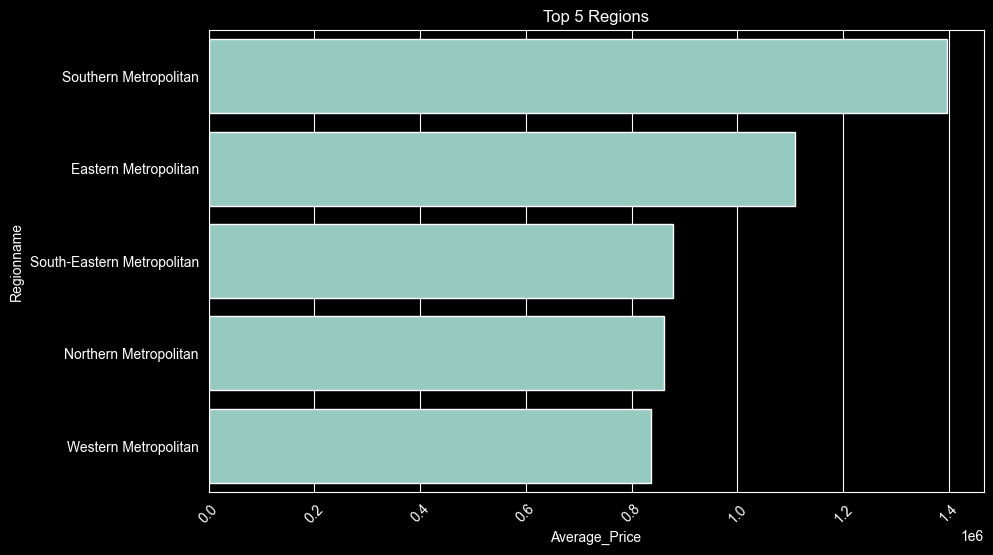

,Suburb,Rooms,Type,Price,Distance,SellerG,Regionname
1,Abbotsford,2,h,1480000.0,2.5,Biggin,Northern Metropolitan
2,Abbotsford,2,h,1035000.0,2.5,Biggin,Northern Metropolitan
4,Abbotsford,3,h,1465000.0,2.5,Biggin,Northern Metropolitan
5,Abbotsford,3,h,850000.0,2.5,Biggin,Northern Metropolitan
6,Abbotsford,4,h,1600000.0,2.5,Nelson,Northern Metropolitan
...,...,...,...,...,...,...,...
34852,Yarraville,4,h,1480000.0,6.3,Jas,Western Metropolitan
34853,Yarraville,2,h,888000.0,6.3,Sweeney,Western Metropolitan
34854,Yarraville,2,t,705000.0,6.3,Jas,Western Metropolitan
34855,Yarraville,3,h,1140000.0,6.3,hockingstuart,Western Metropolitan


In [1]:
import pandas as pd
import urllib.request
import certifi
import ssl
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


context = ssl.create_default_context(cafile=certifi.where())
conn = sqlite3.connect('melbourne_housing.db')
url = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/Melbourne_housing_FULL.csv'


response = urllib.request.urlopen(url, context=context)


raw_data = pd.read_csv(response)
clean_data = raw_data[['Suburb', 'Rooms', 'Type', 'Price', 'Distance','SellerG', 'Regionname']].dropna()
clean_data.to_sql('properties',conn,index=False,if_exists='replace')

query = """
SELECT properties.Regionname,AVG(Price) AS Average_Price
FROM properties
GROUP BY properties.Regionname
ORDER BY  Average_Price DESC
LIMIT 5
"""


df_top_regions = pd.read_sql_query(query,conn)
conn.close()
rt=pd.DataFrame(df_top_regions)
size=plt.figure(figsize = (10,6))
source=sns.barplot(rt,x='Average_Price',y='Regionname')
plt.title('Top 5 Regions')
plt.xticks(rotation=45)
plt.show()



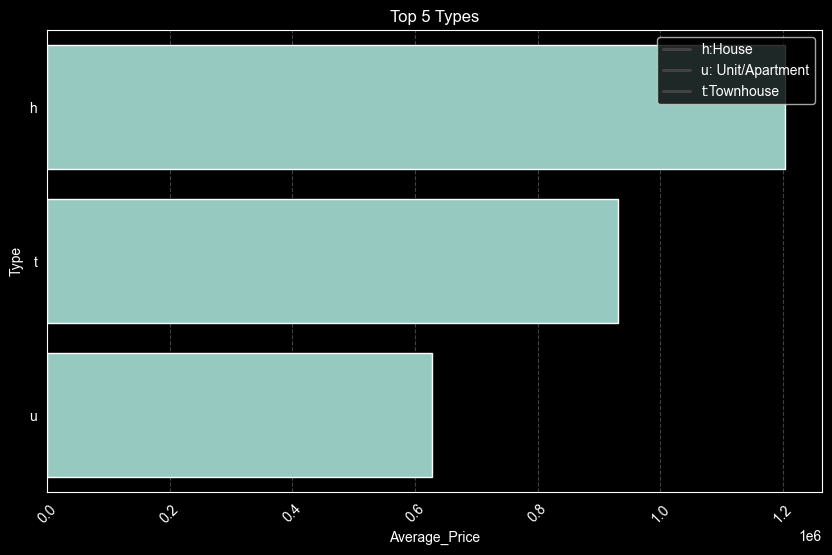

In [1]:


conn = sqlite3.connect('melbourne_housing.db')
query='''
SELECT properties.Type,AVG(Price) AS Average_Price
FROM properties
GROUP BY properties.Type
ORDER BY  Average_Price DESC'''
df_top_TYPEs = pd.read_sql_query(query,conn)
conn.close()
rt=pd.DataFrame(df_top_TYPEs)
plt.figure(figsize = (10,6))
sns.barplot(rt,x='Average_Price',y='Type')
plt.title('Top 5 Types')
plt.xticks(rotation=45)
explanations = ["h:House", "u: Unit/Apartment", "t:Townhouse"]
plt.legend(labels=explanations, title="", loc="upper right")
plt.grid(axis='x', color='gray', linestyle='--', alpha=0.5)




plt.show()


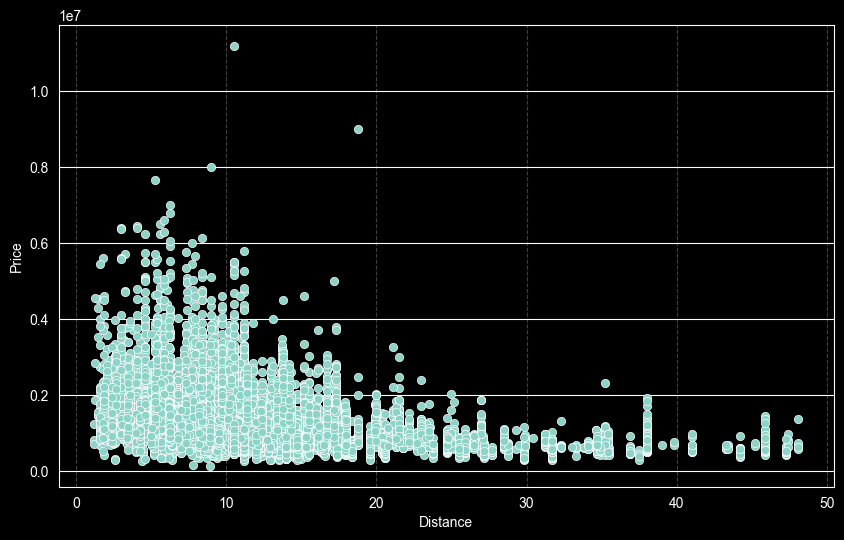

In [21]:


conn = sqlite3.connect('melbourne_housing.db')
query='''
SELECT Price,Distance
FROM properties
WHERE Type='h'
'''
df_distance=pd.read_sql_query(query,conn)
conn.close()

plt.figure(figsize = (10,6))
plt.grid(axis='x', color='gray', linestyle='--', alpha=0.5)
sns.scatterplot(df_distance,x='Distance',y='Price')




plt.show()
